# Handwritten Digit Recognition

Kaggle competition: https://www.kaggle.com/competitions/digit-recognizer/overview

Table of Content
1. [EDA](#eda)
2. [Pytorch](#pytorch)
3. [PyTorch with CNN](#pytorch-cnn)


ref
- https://www.kaggle.com/code/itsmohammadshahid/7-cnn-handwritten-digit-recognition 
- https://www.kaggle.com/code/analyticaobscura/blazing-fast-mnist-with-pytorch-cuda
- https://www.kaggle.com/code/yt776styjsu/99-5-introduction-to-cnn-w-pytorch 

In [68]:
import matplotlib.pyplot as plt
import seaborn as sn
import numpy as np 
import pandas as pd
import math
import datetime
import platform

import os
for dirname, _, filenames in os.walk('.'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

./handwritten-digit-recognition.ipynb
./mnist-original.mat
./submission.csv
./data/.DS_Store
./data/digit-recognizer.zip


# EDA

In [69]:
# Unzip the credit card file, load data to dataframe, then delete the large unzipped csv file

# ==========================
# print all files in the current directory
# import os
# for dirname, _, filenames in os.walk('./'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))
# ==========================

# Step 1: unzip file
from zipfile import ZipFile
with ZipFile('./data/digit-recognizer.zip', 'r') as zip_object:
    zip_object.extractall('./data/digit-recognizer/')

# ==========================
# (Optional) If file is too large, we can divide it and load them to datafram.
# Step 2.1: Divide the original credit card fraud file (150.8MB, too large to upload to Github) into smaller size 
# import pandas as pd

# input_csv_file_path = './data/credit-card-fraud/creditcard.csv'
# rows_per_file = 50_000
# output_prefix = 'data/credit-card-fraud/creditcard_part_'

# csv_reader = pd.read_csv(input_csv_file_path, chunksize=rows_per_file)
# for i, chunk in enumerate(csv_reader):
#     output_file = f'{output_prefix}{i}.csv'
#     chunk.to_csv(output_file, index=False)
#     print(f'Created {output_file}')

# Step 2.2: Load files into a data frame
# import pandas as pd
# import glob

# path = './data/credit-card-fraud/'
# all_files = glob.glob(path + "creditcard_part_*.csv")

# df_list = []
# for filename in all_files:
#     df = pd.read_csv(filename)
#     df_list.append(df)
# df = pd.concat(df_list, ignore_index=True)
# ==========================

# Step 2: load data to dataframe
import pandas as pd
train = pd.read_csv('./data/digit-recognizer/train.csv')
test = pd.read_csv('./data/digit-recognizer/test.csv')

# Step 3: delete extracted csv files and folder
import os
import shutil
input_csv_folder_path = './data/digit-recognizer'
shutil.rmtree(input_csv_folder_path)

In [70]:
train.shape, test.shape

((42000, 785), (28000, 784))

In [71]:
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


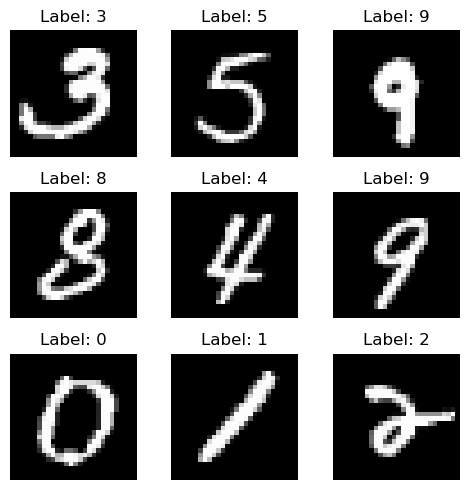

In [72]:
# Plot some random sample images
fig, axes = plt.subplots(3, 3, figsize=(5,5))
axes = axes.ravel()

for i, ax in enumerate(axes):
    random_index = np.random.randint(0, train.shape[0])
    img = train.iloc[random_index, 1:].values.reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Label: {train.iloc[random_index, 0]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [73]:
train.info(), train.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


(None, (42000, 785))

In [74]:
X = train.drop('label', axis=1)
y = train['label']

X_test = test.copy()

### Visualize with TSNE

In [75]:
X_tsn = X/255

from sklearn.manifold import TSNE
tsne = TSNE(random_state=42)
tsne_res = tsne.fit_transform(X_tsn)

In [76]:
tsne_res.shape

(42000, 2)

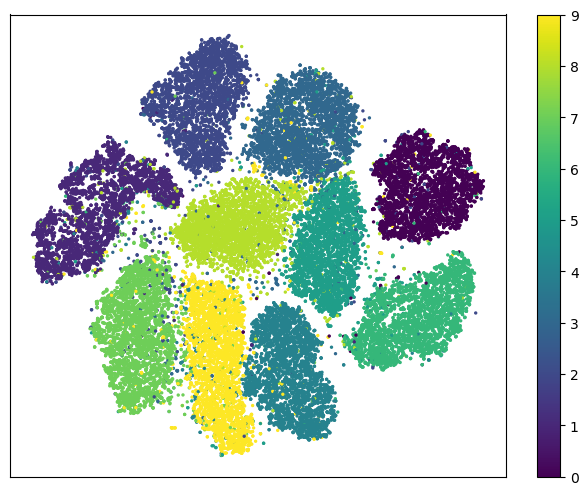

In [77]:
plt.figure(figsize=(8,6))
plt.scatter(tsne_res[:,0], tsne_res[:,1], c=y, s=2)
plt.xticks([])
plt.yticks([])
plt.colorbar();

# PyTorch

In [78]:
import pandas as pd
import numpy as np
import torch
import torch.utils.data
import matplotlib.pyplot as plt
from scipy.io import loadmat
import os
from six.moves import urllib

print("PyTorch version:", torch.__version__)

PyTorch version: 2.6.0


In [79]:
# Check for available devices and set the appropriate device
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"Using {device} device")
print(f"MPS available: {torch.backends.mps.is_available()}")
print(f"CUDA available: {torch.cuda.is_available()}")

Using mps device
MPS available: True
CUDA available: False


In [80]:
# Define the path and URL for the MNIST training data
mnist_path = "mnist-original.mat"
mnist_alternative_url = "https://github.com/amplab/datascience-sp14/raw/master/lab7/mldata/mnist-original.mat"

# Download the training dataset if it doesn't exist
if not os.path.exists(mnist_path):
    print("Downloading MNIST training data...")
    response = urllib.request.urlopen(mnist_alternative_url)
    with open(mnist_path, "wb") as f:
        content = response.read()
        f.write(content)
    print("Download complete.")

# Load the .mat file
mnist_raw = loadmat(mnist_path)

# Extract training images (X) and labels (y)
# The data is stored as (features, samples), so we transpose it with .T
X_train = mnist_raw["data"].T
# Use np.int64 instead of the deprecated np.long
y_train = mnist_raw["label"][0].astype(np.int64)

# Get the test images as a numpy array
X_test = test.to_numpy()

print(f"Shape of training data (X_train): {X_train.shape}")
print(f"Shape of training labels (y_train): {y_train.shape}")
print(f"Shape of test data (X_test):     {X_test.shape}")

Shape of training data (X_train): (70000, 784)
Shape of training labels (y_train): (70000,)
Shape of test data (X_test):     (28000, 784)


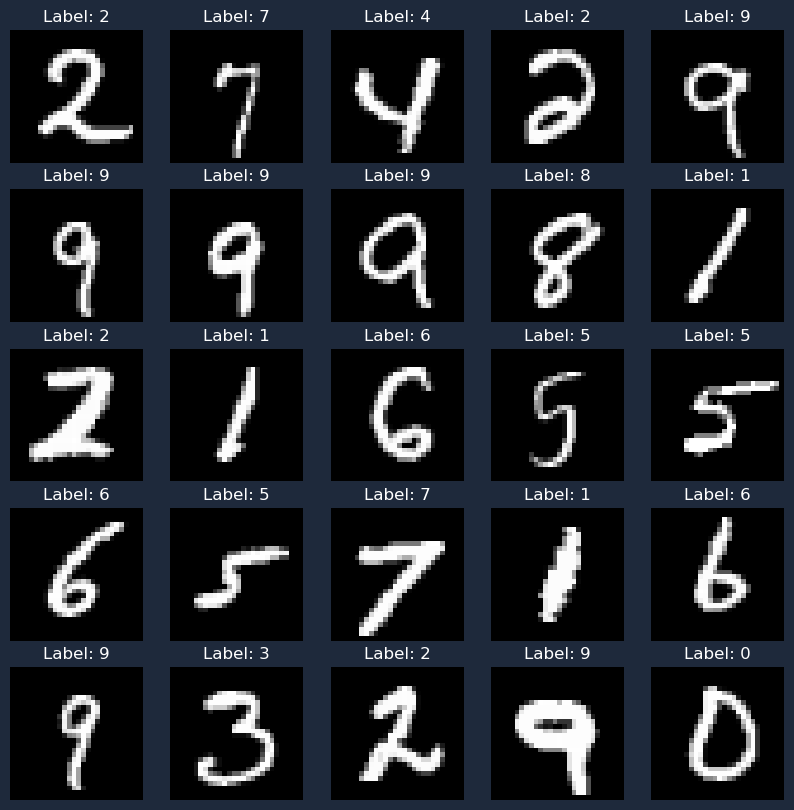

In [81]:
# Plot a grid of 25 random training images
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
axes = axes.ravel()

for i in range(25):
    # Select a random image
    idx = np.random.randint(0, X_train.shape[0])
    image = X_train[idx].reshape(28, 28)
    
    # Plot the image
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f"Label: {int(y_train[idx])}", color='white')
    axes[i].axis('off')

plt.subplots_adjust(hspace=0.2)
fig.patch.set_facecolor('#1e293b')
plt.show()

In [82]:
def pairwise_distances(x, y):
    """
    Calculates the pairwise squared Euclidean distances between two sets of vectors.
    
    Args:
        x (torch.Tensor): A tensor of shape (N, D), where N is the number of vectors in the first set.
        y (torch.Tensor): A tensor of shape (M, D), where M is the number of vectors in the second set.
        
    Returns:
        torch.Tensor: A tensor of shape (N, M) containing the squared distances.
    """
    # Calculate the squared L2 norm of each vector in x
    x_norm = (x**2).sum(1).view(-1, 1)
    
    # Transpose y for matrix multiplication
    y_t = torch.transpose(y, 0, 1)
    
    # Calculate the squared L2 norm of each vector in y
    y_norm = (y**2).sum(1).view(1, -1)
    
    # The core calculation: x_norm + y_norm - 2 * (x @ y_t)
    dist = x_norm + y_norm - 2.0 * torch.mm(x, y_t)
    
    # Clamp the distances to be non-negative to handle potential floating-point inaccuracies
    return torch.clamp(dist, 0.0, np.inf)

In [83]:
%%time

# Move training and test data to the selected device (MPS/CUDA/CPU)
device_train = torch.from_numpy(X_train).to(device).float()
device_test = torch.from_numpy(X_test).to(device).float()

# Create a PyTorch dataset and dataloader for the test data
ds = torch.utils.data.TensorDataset(device_test)
bs = 1000 # Batch size
data_loader = torch.utils.data.DataLoader(ds, batch_size=bs, pin_memory=False)

# Lists to store the results from each batch
_min_dists = []
_arg_min_dists = []

print(f"Processing {len(device_test)} test images in batches of {bs}...")

for i, (batch,) in enumerate(data_loader):
    # Calculate distances from all training images to the current batch of test images
    distances = pairwise_distances(device_train, batch)
    
    # Find the minimum distance and the index of the nearest neighbor for each test image in the batch
    min_dist, arg_min_dist = distances.min(0)
    
    # Append the results
    _min_dists.append(min_dist)
    _arg_min_dists.append(arg_min_dist)
    print(f"  Processed batch {i+1}/{len(data_loader)}")

print("...Processing complete.")

Processing 28000 test images in batches of 1000...
  Processed batch 1/28
  Processed batch 2/28
  Processed batch 3/28
  Processed batch 4/28
  Processed batch 5/28
  Processed batch 6/28
  Processed batch 7/28
  Processed batch 8/28
  Processed batch 9/28
  Processed batch 10/28
  Processed batch 11/28
  Processed batch 12/28
  Processed batch 13/28
  Processed batch 14/28
  Processed batch 15/28
  Processed batch 16/28
  Processed batch 17/28
  Processed batch 18/28
  Processed batch 19/28
  Processed batch 20/28
  Processed batch 21/28
  Processed batch 22/28
  Processed batch 23/28
  Processed batch 24/28
  Processed batch 25/28
  Processed batch 26/28
  Processed batch 27/28
  Processed batch 28/28
...Processing complete.
CPU times: user 226 ms, sys: 42.8 ms, total: 269 ms
Wall time: 470 ms


In [84]:
# Concatenate the lists of results into single tensors
min_dists = torch.cat(_min_dists)
arg_min_dists = torch.cat(_arg_min_dists)

# Check how many test samples were not found as exact matches in the training set
not_found_count = len(min_dists[min_dists > 0])
print(f'Number of not found samples (distance > 0): {not_found_count}')

Number of not found samples (distance > 0): 3


In [85]:
# Create a dummy sample submission if not found
try:
    sub = pd.read_csv('../input/digit-recognizer/sample_submission.csv')
except FileNotFoundError:
    print("Sample submission not found. Creating a dummy one.")
    sub = pd.DataFrame({'ImageId': range(1, len(X_test) + 1), 'Label': 0})


# Get the predicted labels by indexing y_train with our results
# We need to move the indices from the GPU to the CPU first with .cpu()
predicted_labels = y_train[arg_min_dists.cpu()]

# Assign the predicted labels to the submission DataFrame
sub['Label'] = predicted_labels

# Save the submission file
sub.to_csv('submission.csv', index=False)

# Print the first few lines of our submission file
print("Submission file created successfully!")
print("Head of submission.csv:")
print(sub.head())

Sample submission not found. Creating a dummy one.
Submission file created successfully!
Head of submission.csv:
   ImageId  Label
0        1      2
1        2      0
2        3      9
3        4      0
4        5      3


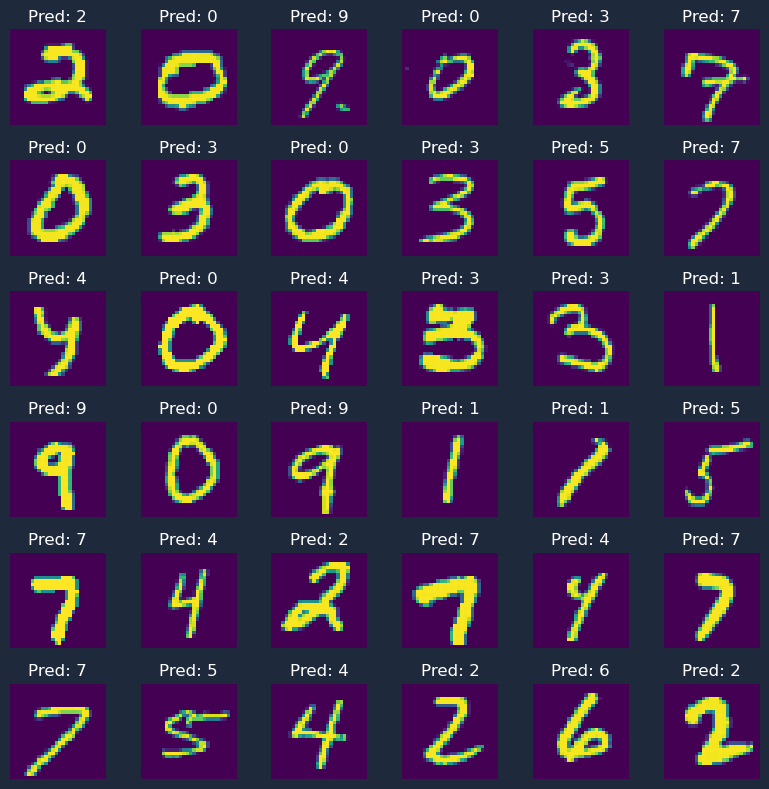

In [86]:
# Visualize the first 36 predictions
fig, axs = plt.subplots(6, 6, figsize=(8, 8))

for i, ax in enumerate(axs.flatten()):
    if i < len(sub):
        # Set the title to our predicted label
        ax.set_title(f"Pred: {sub.Label[i]}", color='white', fontsize=12)
        
        # Display the test image
        ax.imshow(X_test[i].reshape(28, 28), cmap='viridis')
        
        # Turn off axis ticks and labels
        ax.axis('off')

fig.patch.set_facecolor('#1e293b')
plt.tight_layout()
plt.show()

# PyTorch CNN

In [100]:
import numpy as np # data processing
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import torch # PyTorch
from torch.utils.data import Dataset, DataLoader # data loading
from torchvision import transforms # data processing
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as opt # optimizer
from torch.utils.data.sampler import SubsetRandomSampler # data pre-processing

In [101]:
train_set = train.copy()
test_set = test.copy()

AttributeError: 'function' object has no attribute 'copy'

In [103]:
VALID_SIZE = 0.1 # Percentage of data for validation

num_train = len(train_set)
indices = list(range(num_train))
np.random.shuffle(indices)
split = int(np.floor(VALID_SIZE * num_train))
train_indices, valid_indices = indices[split:], indices[:split]

train_sampler = SubsetRandomSampler(train_indices)
valid_sampler = SubsetRandomSampler(valid_indices)

print(f'training set length: {len(train_indices)}')
print(f'validation set length: {len(valid_indices)}')

training set length: 37800
validation set length: 4200


In [104]:
class DatasetMNIST(Dataset):
    def __init__(self, data, transform=None, labeled=True):
        self.data = data
        self.transform = transform
        self.labeled = labeled

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):  # Defines how Dataloader will load the items
        item = self.data.iloc[index]
        if self.labeled:
            x = item[1:].values.astype(np.uint8).reshape((28, 28))  # Pixel data
            y = item[0]  # Label
        else:
            x = item[0:].values.astype(np.uint8).reshape((28, 28))  # Pixel data
            y = 0  # Dummy label for test set

        if self.transform is not None:
            x = self.transform(x)

        return x, y

In [105]:
# Transform the dataset
transform_train = transforms.Compose([
    transforms.ToPILImage(), # allows the following transformation to be applied
    transforms.RandomAffine(degrees=10, translate=(0, 0.1), scale=(0.9, 1.1)), # random rotations, translations, and scaling
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # normalize data to speed up convergence for gradient descent
    # Mean Pixel Value / 255 = 33.31002426147461 / 255 = 0.1307
    # Pixel Values Std / 255 = 78.56748962402344 / 255 = 0.3081
    # IMPORTANT: I did not show how the mean and standard deviation are calculated. I looked up those two values 
    #            in the original MNIST, which is against the rules because the original MNIST included the test set. 
    #            Instead, we should take a sample from the training set and compute the mean and standard deviation. 
    #            If I have time, I'll add to this notebook and fix the problem.
])

transform_valid = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [106]:
# Creating datasets for training, validation, and test
train_data = DatasetMNIST(train_set, transform=transform_train)
valid_data = DatasetMNIST(train_set, transform=transform_valid)
test_data = DatasetMNIST(test_set, transform=transform_test, labeled=False)

In [107]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.dr = nn.Dropout(p=0.4)
        self.conv1 = nn.Conv2d(1, 32, (3, 3))  # Output becomes 26x26
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, (3, 3))  # Output becomes 24x24
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 32, (5, 5), stride=(2, 2))  # Output becomes 10x10
        self.bn3 = nn.BatchNorm2d(32)
        self.conv4 = nn.Conv2d(32, 64, (3, 3))  # Output becomes 8x8
        self.bn4 = nn.BatchNorm2d(64)
        self.conv5 = nn.Conv2d(64, 64, (3, 3))  # Output becomes 6x6
        self.bn5 = nn.BatchNorm2d(64)
        self.conv6 = nn.Conv2d(64, 64, (5, 5), stride=(2, 2))  # Output becomes 1x1
        self.bn6 = nn.BatchNorm2d(64)
        self.fc1 = nn.Linear(64 * 1 * 1, 128)  # Num of features * dimension of the output 
        self.bn7 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 10)
        
    def forward(self, x):
        x = self.bn1(F.relu(self.conv1(x)))
        x = self.bn2(F.relu(self.conv2(x)))
        x = self.dr(self.bn3((F.relu(self.conv3(x)))))
        x = self.bn4(F.relu(self.conv4(x)))
        x = self.bn5(F.relu(self.conv5(x)))
        x = self.dr(self.bn6(F.relu(self.conv6(x))))
        x = x.view(-1, 64 * 1 * 1)
        x = self.dr(self.bn7(F.relu(self.fc1(x))))
        x = self.fc2(x)
        
        return x

In [108]:
# Hyperparameters
NUM_EPOCHS = 35
BATCH_SIZE = 64
LEARNING_RATE = 0.001

In [109]:
train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, sampler=train_sampler)
valid_dataloader = DataLoader(dataset=valid_data, sampler=valid_sampler)
test_dataloader = DataLoader(dataset=test_data)

In [110]:
model = ConvNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Reduce learning rate as the training progresses for producing more locally optimal results
lr_scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)


def train():
    n_total_steps = len(train_dataloader)  # Displaying loss once at the every end of an epoch
    for epoch in range(NUM_EPOCHS):
        model.train()  # Sets the module in training mode
        for i, (images, labels) in enumerate(train_dataloader):
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward and optimize
            optimizer.zero_grad()  # Sets the gradients of all optimized torch.Tensor to zero.
            loss.backward()  # Computes dloss/dx for every parameter x which has requires_grad=True
            optimizer.step()  # Updates the value of x using the gradient x.grad.
            if (i + 1) % n_total_steps == 0:
                print(
                    f'Epoch [{epoch + 1}/{NUM_EPOCHS}], Step [{i + 1}/{n_total_steps}, Loss = {loss.item():4f}]'
                )

        lr_scheduler.step()
        print('Current learning rate:', optimizer.param_groups[0]['lr'])
        get_valid_acc()  # Defined in 5.1. Checking Accuracy on Validation Set

In [111]:
# Test accuracy on validation set
def get_valid_acc():
    # Temporarily set the attribute requires_grad of tensors to False 
    # and deactivates the Autograd engine which computes the gradients with respect to parameters
    # as we do not need backpropagation for evaluation. 
    with torch.no_grad():
        # Sets the module in evaluating mode
        # Ignoring layers including dropout, etc. to produce the correct outputs
        model.eval()
        n_correct = 0
        n_samples = 0
        for images, labels in valid_dataloader:
            images = images.reshape(-1, 1, 28, 28).to(device)
            labels = labels.to(device)
            outputs = model(images)

            predictions = outputs.to(device).data.max(1, keepdim=True)[1]
            n_samples += labels.shape[0]
            n_correct += (predictions == labels).sum().item()

        acc = 100.0 * n_correct / n_samples
        print(f'Validation set accuracy = {acc}')

In [112]:
# def check(directory):
#     answer_set = pd.read_csv('./labeled-test-set-do-not-submit/answer.csv')
#     submission_set = pd.read_csv(directory)

#     n_correct = 0
#     n_samples = 0

#     for i in range(28000):
#         if answer_set.iloc[i][1] == submission_set.iloc[i][1]:
#             n_correct += 1
#         n_samples += 1

#     acc = 100.0 * n_correct / n_samples
#     print(f'test set accuracy = {acc}')

In [ ]:
train()  # Starts training


# Run the model on test set and generate submission.csv
with torch.no_grad():
    model.eval()
    results = torch.ShortTensor()
    for predict_images, _ in test_dataloader:
        predict_images = predict_images.reshape(-1, 1, 28, 28).to(device)
        predict_outputs = model(predict_images)
        test_predictions = predict_outputs.cpu().data.max(1, keepdim=True)[1]
        results = torch.cat((results, test_predictions), dim=0)

    submission = pd.DataFrame(np.c_[np.arange(1, len(test_set) + 1)[:, None], results.numpy()],
                              columns=['ImageId', 'Label'])
    # submission.to_csv('/kaggle/working/submission.csv', index=False)
    # check('/kaggle/working/submission.csv')  # Get test set accuracy

/var/folders/_r/4hrx01cn3dq3vh48fym1jff00000gn/T/ipykernel_3572/3847585938.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y = item[0]  # Label


Epoch [1/35], Step [591/591, Loss = 0.266397]
Current learning rate: 0.0009000000000000001
Validation set accuracy = 98.14285714285714
Epoch [2/35], Step [591/591, Loss = 0.391441]
Current learning rate: 0.0008100000000000001
Validation set accuracy = 98.52380952380952
Epoch [3/35], Step [591/591, Loss = 0.206967]
Current learning rate: 0.000729
Validation set accuracy = 98.66666666666667
Epoch [4/35], Step [591/591, Loss = 0.170627]
Current learning rate: 0.0006561000000000001
Validation set accuracy = 98.61904761904762
Epoch [5/35], Step [591/591, Loss = 0.024486]
Current learning rate: 0.00059049
Validation set accuracy = 99.02380952380952
Epoch [6/35], Step [591/591, Loss = 0.040948]
Current learning rate: 0.000531441
Validation set accuracy = 98.95238095238095
Epoch [7/35], Step [591/591, Loss = 0.063602]
Current learning rate: 0.0004782969
Validation set accuracy = 99.21428571428571
Epoch [8/35], Step [591/591, Loss = 0.006567]
Current learning rate: 0.00043046721
Validation set 

OSError: Cannot save file into a non-existent directory: '/kaggle/working'